# Customer Segmentation using K-Means

This project aims to segment customers based on purchasing behavior 
(sales, profit, quantity) to identify high-value and low-value customers 
for targeted business strategies.

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## 1. Data Preparation


In [2]:
df = pd.read_csv(r'C:\Users\hp\Projects\ecommerce-data-analytics-ml\data\Ecommerce_Sales_Data.csv')

In [3]:
df.head()

,order_id,order_date,customer_name,region,city,category,sub_category,product_name,quantity,unit_price,discount,sales,profit,payment_mode
0,10001,19-10-2024,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,30-08-2025,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,04-11-2023,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,23-05-2025,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,19-01-2025,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


## 2. Feature Selection


In [4]:
customer_df = df.groupby('customer_name').agg({
    'sales': 'sum',
    'profit': 'sum',
    'quantity': 'sum'
}).reset_index()

In [6]:
X = customer_df[['sales','profit','quantity']]

## 3. Feature Scaling


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. K-Means Model


In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

## 5. Cluster Analysis


In [10]:
customer_df.groupby('Cluster')[['sales','profit','quantity']].mean()

,sales,profit,quantity
Cluster,,,
0,108486.363925,14899.650516,3.854839
1,251018.457656,40991.968237,4.658923
2,46228.231738,6468.331384,1.659794


## 6. Business Interpretation

Cluster 1 (High-value customers):
These customers generate the highest average sales (~251k) and profit (~40k), making them the most valuable segment. They should be prioritized through loyalty programs and personalized offers to maximize retention and lifetime value.

Cluster 2 (Low-value customers):
These customers contribute the lowest sales (~46k) and profit (~6k), indicating minimal engagement. Marketing efforts should focus on converting them into higher-value segments through targeted promotions or discounts.

Cluster 0 (Medium-value customers):
These customers show moderate sales (~108k) and profit (~14k), representing a growth opportunity. With targeted upselling and cross-selling strategies, they can be converted into high-value customers.

# Key ML Insights

- A small segment of customers contributes disproportionately high revenue, making retention strategies critical.
- Low-value customers represent an opportunity for growth through targeted promotions.
- Medium-value customers can be converted into high-value customers using upselling techniques.

Text(0.5, 1.0, 'Customer Segmentation')

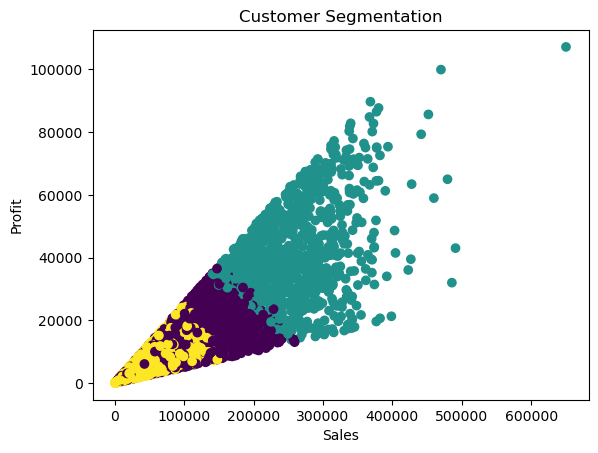

In [16]:
plt.scatter(customer_df['sales'], customer_df['profit'], c=customer_df['Cluster'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Customer Segmentation")

The scatter plot shows a positive relationship between sales and profit, indicating that higher sales generally lead to higher profitability. The clustering algorithm has grouped customers into three segments, with high-value customers concentrated in the upper-right region and low-value customers in the lower-left region. However, there is noticeable overlap between medium and high-value clusters, suggesting that customer behavior lies on a spectrum rather than forming sharply separated groups. This indicates that while segmentation is useful, boundaries between customer segments are not strictly defined.

# Final Conclusion

• Customers are clearly segmented into three groups based on purchasing behavior  
• High-value customers contribute the most revenue and should be prioritized for retention  
• Medium-value customers represent growth potential through upselling  
• Low-value customers require targeted marketing to improve engagement  